In [5]:
import os
from ParseEvent import ParseEvent
import pickle
import cv2

def get_video_info(video_path):
    # 打开视频文件
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        raise ValueError("无法打开视频文件，请检查路径是否正确！")
    
    # 获取视频的基本信息
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))  # 总帧数
    fps = cap.get(cv2.CAP_PROP_FPS)  # 帧率
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))  # 视频宽度
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))  # 视频高度
    
    # 释放资源
    cap.release()
    
    return {
        "total_frames": total_frames,
        "fps": fps,
        "width": width,
        "height": height,
        "duration": total_frames / fps if fps > 0 else 0  # 计算视频时长（秒）
    }

dir = 'temp' 
def find_evt_files_without_pkl(dir=str):
    evt_files_without_pkl = []
    video_files = []
    txtPaths = []
    for root, dirs, files in os.walk(dir):
        for file in files:
            if file.endswith('.evt'):
                pkl_file_name = os.path.splitext(file)[0] + '.pkl'
                if pkl_file_name not in files:
                    evt_file_path = os.path.join(root, file)
                    evt_files_without_pkl.append(evt_file_path)
            elif file.endswith('.mp4'):
                video_file_path = os.path.join(root, file)
                video_files.append(video_file_path)
            elif file.endswith('_rec.txt'):
                txt_file_path = os.path.join(root, file)
                txtPaths.append(txt_file_path)
    
    return evt_files_without_pkl, video_files, txtPaths

evtPaths, videoPaths, txtPaths = find_evt_files_without_pkl(dir)
count=0
Event=None
if(len(evtPaths)==0):
    print('No evt to be processed!\n')
else:
    print('Find '+str(len(evtPaths))+' File(s)!')

Find 1 File(s)!


In [6]:
# You can edit data here

Event=ParseEvent(evtPaths[0])
print('Processing file '+str(count+1)+'/'+str(len(evtPaths))+': '+evtPaths[0])
for video in videoPaths:
    print(get_video_info(video))

Processing file 1/1: temp\2025_04_17_21_00_evt.evt


In [12]:
import numpy as np
import pandas as pd
def auto_align_with_ratio(ref, noisy, ratio, tolerance=0.15):
    if len(ref) == 0 or len(noisy) == 0:
        raise ValueError("Empty input")
    
    ref = np.asarray(ref)
    noisy = np.asarray(noisy)
    refdiff:np.ndarray = np.diff(ref) * ratio
    noisydiff = np.diff(noisy)
    refdiffReverse = np.flip(refdiff)

    diffDiff = []
    for noise in noisy[(len(ref) - 1):]:
        tempRes = [noise]
        minused = noise
        for rdiff in refdiffReverse:
            minused = minused - rdiff
            tempRes.append(minused)

        diffDiff.append(np.flip(tempRes))

    
    indicesMatch = []
    indicesMatchDiff = []
    for noisyMinusDiff in diffDiff:
        tempindicesMatch = []
         
        for minusedDiff in noisyMinusDiff:
        # 检查数据数组中是否存在一个元素在 ref ± tolerance 范围内
            found = any(abs(d - minusedDiff) <= tolerance for d in noisy)
            if not found:
                break
        else:
            for rightMinusedDiff in noisyMinusDiff:
                indices = np.asarray([i for i, d in enumerate(noisy) if abs(d - rightMinusedDiff) <= tolerance])
                if len(indices) == 1:
                    tempindicesMatch.append(indices[0])
                else:
                    matchdiff = abs(noisy[indices] - rightMinusedDiff)#对当前潜在预测找到原始数据中最符合潜在预测的值
                    tempindicesMatch.append(indices[np.where(matchdiff == min(matchdiff))[0][0]])
        indicesMatch.append(tempindicesMatch)
        if len(tempindicesMatch) == len(ref):
            indicesMatchDiff.append(np.sum(abs(noisy[np.array(tempindicesMatch)] - ref * ratio)))
        else:
            indicesMatchDiff.append(-1)
    
    indicesMatchDiff = np.asarray(indicesMatchDiff)
    if np.all(indicesMatchDiff < 0):
        raise ValueError("No match found")
    bestMatchInd = np.where(indicesMatchDiff == min(indicesMatchDiff[indicesMatchDiff >= 0]))[0][0]
    bestMatch = indicesMatch[bestMatchInd]
    
    return bestMatch

def AlignProjectBackToUnityTime(timesInLogevent, offset)-> np.ndarray:
    return (np.asarray(timesInLogevent) - offset) / 50000

def ResampleByStartTime(eventStart, eventIndex, manipulateStart, manipulateEnd):
    """
    找出控制时间段内发生的目标事件及其标签
    
    参数:
        eventStart: 目标事件开始时间列表
        eventIndex: 目标事件标签列表(与target_starts长度相同)
        manipulateStart: 控制事件开始时间列表
        manipulateEnd: 控制事件结束时间列表
    
    返回:
        一个列表，每个元素是一个元组，包含:
        (控制时间段索引, 该控制时间段内发生的目标事件索引列表, 对应的标签列表)
    """
    # 首先确保输入数据长度匹配
    assert len(eventStart) == len(eventIndex), "目标事件开始时间和标签列表长度不一致"
    assert len(manipulateStart) == len(manipulateEnd), "控制事件开始和结束时间列表长度不一致"
    
    result = []
    
    # 遍历每个控制时间段

    for control_idx, (ctrl_start, ctrl_end) in enumerate(zip(manipulateStart, manipulateEnd)):
        # 检查时间有效性
        if ctrl_start > ctrl_end:
            continue  # 或者可以抛出异常，取决于你的需求
            
        # 存储当前控制时间段内的目标事件索引和标签
        target_indices = []
        # half_target_indices = []
        target_labels_in_period = []
        
        # 检查每个目标事件是否在当前控制时间段内
        for target_idx, (t_start, label) in enumerate(zip(eventStart, eventIndex)):
            if t_start - ctrl_start > -0.5 and t_start < ctrl_end:
                target_indices.append(target_idx)
                target_labels_in_period.append(label)
            # elif target_idx :
        # 添加到结果中
        # result.append((control_idx, target_indices, target_labels_in_period))
        result += target_labels_in_period
    
    return result

def IsValidDataLine(line:str) -> bool:
    splited = line.split('\t')
    if len(splited) == 6:
        try:
            float(splited[1])
            int(splited[3])
            return True
        except:
            return False
    return False

limitedColumns = ['type', 'delta time', 'mode', 'trial', 'lickPos', 'result']

def readToDataRows(_fname, _dataRows, _addtion:list = None):
    _config = ""
    with open(_fname, 'r') as file:
        for line in file:
            line.strip()
            if IsValidDataLine(line):
                # 按制表符分割行，并添加到数据行列表中
                _dataRows.append(line.strip().split('\t')[0:len(limitedColumns)])
                #if len(dataRows) > 1:
                    #dataRows[-1][1] = float(dataRows[-1][1])
                #dataRowsTyped.append(dataRows[-1])
            elif line.startswith("{"):
                _config += line + "\n"
            if _addtion is not None:
                if "Trial initialized" in line:
                    _addtion.clear()
                if "started at " in line:
                    _addtion.append(line[line.index("started at "):line.index("started at ") + 1])

def CheckTrialIntegrity(tempDf:pd.DataFrame) -> bool:
        essentialTypes = ['stay']
        for essentialType in essentialTypes:
            if essentialType not in tempDf['type'].values:
                return False
        return True

_datarows = []
readToDataRows(txtPaths[0], _datarows)

RecMainDf = pd.DataFrame(_datarows, columns=limitedColumns)
RecMainDf = RecMainDf.drop(RecMainDf.index[RecMainDf['type'] == "type"])
RecMainDf['delta time'] = np.float64(RecMainDf['delta time'])

startIndices    =          RecMainDf.index[RecMainDf['type'] == "start"]#trial处理均以开始结束Index为标准
EndIndices      =          RecMainDf.index[RecMainDf['type'] == "end"]
licks           = np.array(RecMainDf.loc[RecMainDf["type"] == "lick"]["delta time"])
startIndices.delete(range(len(EndIndices), len(startIndices)))

ignoreFristTrials = 15
ignoreLastTrials = 15
fristIgnoredTrials = 0
lastIgnoredTrials = 0
trials = []
for i in range(1, len(EndIndices)):
            # _i = i - popOffset
    trials.append(         RecMainDf.loc[startIndices[i-1] : startIndices[i], :])
    tempResult:int      = int(  RecMainDf.loc[EndIndices[     i - 1]]["result"])

    tempStartTime       =       RecMainDf.loc[startIndices[   i - 1]]['delta time']
    tempTrackStartTime  =       RecMainDf.loc[EndIndices[     i - 2]]['delta time'] if i > 1 else RecMainDf.loc[startIndices[   i - 1]]['delta time']
    tempEndTime         =       RecMainDf.loc[EndIndices[     i - 1]]['delta time']
    
    tempDf = trials[-1]

    if CheckTrialIntegrity(tempDf) and tempResult >= 0 and tempEndTime - tempStartTime < 360:
        pass
    else:
        trials.pop()
        if i < ignoreFristTrials:
            fristIgnoredTrials += 1
        elif i > len(EndIndices) - ignoreLastTrials:
            lastIgnoredTrials += 1
fullTrialCount = len(trials)
trials = trials[ignoreFristTrials - fristIgnoredTrials: min(fullTrialCount - ignoreLastTrials + lastIgnoredTrials, 350)]

trialEventTimeNow={}
trialStartTimes = []
trialEndTimes = []
trialFinishTimes = []
for i, tempDf in enumerate(trials):
    # tempDf:pd.DataFrame = MouseRecords[mouseInd].Days[day].trials[trialInd]
    _startTime = tempDf.loc[tempDf['type'] == 'start']['delta time'].values[0]
    _endTime = tempDf.loc[tempDf['type'] == 'end']['delta time'].values[0]
    _finishTime = tempDf.loc[(tempDf['lickPos'] == '-3')]['delta time'].values[0]
    trialStartTimes.append(_startTime)
    trialEndTimes.append(_endTime)
    trialFinishTimes.append(_finishTime)


trialEventTimeNow['start'] = np.array(trialStartTimes)
        #End可能不在文件中记录，对齐后直接判断

            # trialEventTime[mouseInd][day].append((_startTime, _endTime, _finishTime))

[]
[]
958211
31


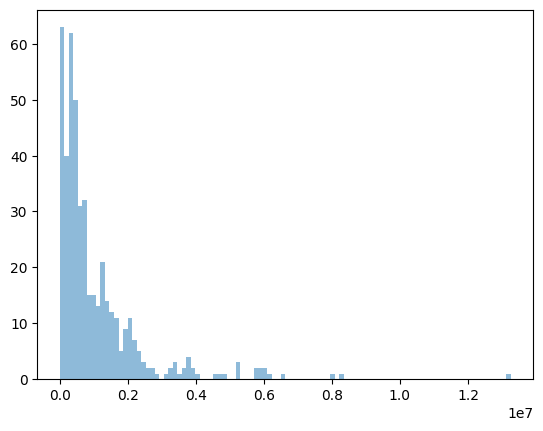

In [13]:
import numpy as np
import matplotlib.pyplot as plt

msStart = Event['MsEnable']['Time_S']
msEnd = Event['MsEnable']['Time_E']
print(msStart)
print(msEnd)
msStart = np.array(Event['MsSync']['Time_E'])
pump = np.array(Event['Pump0']['Time_E'])
msDif = msStart[1:] - msStart[:-1]

bsStart = np.array(Event['BaslerSync']['Time_S'])
print(len(bsStart))

vsStart = np.array(Event['VisualStimulate']['Time_S'])
vsDif = vsStart[1:] - vsStart[:-1]
trialStartAlign = aligned_indices = auto_align_with_ratio(
                    trialEventTimeNow['start'],
                    Event['VisualStimulate']['Time_E'],
                    ratio=50000,
                    tolerance=25000
                )
trialStartTimeInLogevent = np.asarray(Event['VisualStimulate']['Time_E'])[np.array(trialStartAlign)]
# print(len(vsStart[(vsDif < 1000) & (vsDif > 500)]))
print(len(vsDif[vsDif < 2 * 500]))
# fig = plt.figure(figsize=(20, 3), dpi=500)
# axe = fig.add_subplot(111)

# plt.scatter(vsStart, np.zeros_like(vsStart), marker='o', s=10, c='r')
plt.hist(vsDif, bins=100, alpha=0.5, label='VisualStimulate')
# axe.scatter(pump, np.ones_like(pump), marker='o', s=10, c='b')
plt.show()
for i, t in enumerate(Event['MsEnable']['Time_S']):
    end = msEnd[i] + 10000
    tempSyncS = np.array(Event['MsSync']['Time_S'])
    tempSyncE = np.array(Event['MsSync']['Time_E'])
    print(f'chunk{i}')
    print(len(np.where((tempSyncS > t) & (tempSyncS < end))[0]))
    print(len(np.where((tempSyncE > t) & (tempSyncE < end))[0]))


In [14]:
if (Event != None):
    # pkl_path=os.path.splitext(evtPaths[count])[0] + '.pkl'
    pkl_path='logeventpkl/' + os.path.splitext(evtPaths[count])[0].split('\\')[-1] + '.pkl'
    with open(pkl_path,"wb") as pkl_f:
        pickle.dump(Event,pkl_f)
        Event=None
    print('File Saved!\n')

File Saved!

